# **STAGE 2 - ETL**

## **Objectives**

In this Jupyter Notebook, I will be following the ETL process on the raw dataset: `bank-churners-anonymised.csv`

The process will be as follows:
* **Extract**: I will load the dataset into a pandas DataFrame and perform an initial inspection of its structure, data types and quality.
* **Transform**: I will clean and standardise the dataset, change data types where necessary, remove any null values, and engineer new features.
* **Load**: Finally, I will export the cleaned DataFrame as a new CSV file, ready to be used in the next Jupyter Notebook - **Stage 3 - Visualisation**.

## **Inputs**

* The data input I need for this section is an anonymised dataset created during **Stage 1 - Anonymise**
* It is found in my project here: `datasets/anonymised-raw-data/bank-churners-anonymised.csv`.

## **Outputs**

* At the end of this notebook, I created a new .csv file which has been cleaned and is ready for analysis.
* The relative path for this .csv file is: `datasets/cleaned-data/bank-churners-cleaned.csv`

---

## **Change Working Directory**

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/credit-card-customer-churn-analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/credit-card-customer-churn-analysis'

---

## **Import Packages and Libraries**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_palette("PiYG", n_colors=6)

---

## **Core Statistical Concepts**

Before diving into this project, I am first going to outline some key statistical concepts that are foundational to data analysis. Because many of these will appear in my project, it is important to outline what they mean and how they are used.

I'll split these up into three main sections: 

### **Descriptive Statistics**
Descriptive statistics summarise features of a data set. They can describe things like the **central tendency** and the **variability**.

| **Concept** | **Sub-Concept** | **Description** |
| ---------- | --------------| -------- |
| **Central Tendency** | - | The central tendency refers to a value that shows the middle or typical point in a dataset. |
| - | **Mean** | The mean is the average value of a dataset. <br><br>***How to Calculate***: Add all the values together and divide by the total number of observations. <br><br>***Pandas method to calculate***: Use `.mean()`. <br><br> The mean provides a simple measure of the central tendency of the data, although it can be strongly affected by unusually large or small values (outliers). |
| - | **Median** | The median is the middle value - it can be thought of as the element that divides the data into two equal parts. <br><br>***How to Calculate***: Arrange the data in ascending or descending order. If the number of elements is odd, the median is the middle element in the arranged values. If the number of observations is even, the median is given by the mean of the two middle elements. <br><br>***Pandas method to calculate***: Use `.median()`. <br><br>Unlike the mean, the median is less affected by outliers, making it useful for datasets with skewed distributions. |
| - | **Mode** | The mode is the value that appears most often (has the highest frequency) in a dataset. <br><br>***How to Calculate***: The easiest way is to order the numbers in ascending or descending order. Then, count the number of times a value appears. <br><br>***Pandas method to Calculate***: Use `.mode()`. <br><br>A dataset can be **Uni-modal** (only one mode), **Bi-modal** (two modes), or **Multi-modal** (more than two modes). |
| **Variability** | - | Measures of variability are also known as dispersion or spread and show how spread out the data is. Some of the ways to measure this are **standard deviation**, **range** and **variance**. |
| - | **Standard Deviation** | Standard deviation measures how spread out the observations are around the mean. It is used by data analysts to assess the distribution of the data. A small standard deviation means values tend to be close to the mean. A large standard deviation indicates greater variability. |

### **Inferential Statistics**
Whereas descriptive statistics summarise the data you have, inferential statistics use data to draw conclusions beyond the observed sample.

| **Concept** | **Sub-Concept** | **Description** |
| ---------- | --------------| -------- |
| **Hypothesis Testing** | - | This is a statistical method used to determine whether there is sufficient evidence to support a claim. <br><br> A **null hypothesis (H0)** represents no effect or difference, and an **alternative hypothesis (Ha or H1)**, which represents an effect or difference. A statistical test and a significance level are then used to determine whether the evidence is strong enough to reject the null hypothesis. |

### **Probability**
Statistical probability measures how likely an event is to occur and is expressed as a number between 0 and 1.

| **Concept** | **Sub-Concept** | **Description** |
| ---------- | --------------| -------- |
| **p-value** | - | The p-value is a statistical measure and specific probability that tells you the likelihood that an observed outcome is the result of chance or that it could have occured under the null hypothesis. It tells you whether a result is **statistically significant**. |

### **Why are these core concepts so important in Data Analysis?**
All of the concepts listed together are the foundation of data analyis. They help to transform raw data into meaningful information and help to support evidence-based decision-making.

> *Notes on Process*:
<br><br>This section has been copied over from the last Code Institute project I submitted, so the write-up will be the same.
<br><br>

---

## **1. Extraction**

In this first section, Extraction, I am looking to gain a baseline understanding of what my data looks like before I move on to cleaning and transforming.

I am using the acronym - **DISH** - to guide this process, where the letters stand for:

| Letter | Function / Attribute |
| ------ | ------- |
|**D**| `.describe`|
|**I**| `.info()`|
|**S**| `.shape`|
|**H**| `.head()`|

I will also use the following extraction steps:

| Function / Attribute |
| -----|
|`.dtypes`|
|`.isnull.sum()`|

### **1.1 Load the Raw Dataset**

Firstly, I will load the raw dataset - `bank-churners-anonymised.csv` - that I am going to be working on for this ETL Jupyter Notebook.

In [5]:
# Load the raw dataset
df_anonymised = pd.read_csv("datasets/anonymised-raw-data/bank-churners-anonymised.csv")

# Display the first few rows of the dataset to make sure the data has loaded correctly
df_anonymised.head()

,anonymised_clientnum,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,022e52f0a251431f954db620fd0c87ac3c523c60cc5980...,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,2731de4ed9ecb2a3ab828448bfda6137e5c7571e1f7576...,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,75dac624c2bbdb15b16abc0350820bcf598c012a76b102...,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,1aaada0cd1f7dc23d83a171beec9f398cfac1471841843...,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,1811f55b3210153f77e41ceceb61cc181d2edc4e65947e...,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


### **1.2 Display the Shape of the Dataset**

In [6]:
# Display the shape of the dataset
print(f"Shape of the dataset: {df_anonymised.shape}")

Shape of the dataset: (10127, 21)


The dataset has 10,127 rows and 21 columns.

### **1.3 Display the Data Types for each Column**

In order to identify any data type mismatches, I am going to inspect the data types for each column of my DataFrame.

In [7]:
# Outline the data types of each column in the dataset
print(f"Data types of each column:\n\n{df_anonymised.dtypes}")

Data types of each column:

anonymised_clientnum         object
Attrition_Flag               object
Customer_Age                  int64
Gender                       object
Dependent_count               int64
Education_Level              object
Marital_Status               object
Income_Category              object
Card_Category                object
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object


The only columns I want to change here are `Total_Trans_Amt` and `Total_Revolving_Bal`: these are both listed as integers, but because they refer to a currency amount, I want to store them as floats. I will do this in my **Transform** section. 

### **1.4 Display a Summary of all Columns**

In [8]:
# Use .info() to get a concise summary of the dataset, including the number of non-null entries
df_anonymised.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   anonymised_clientnum      10127 non-null  object 
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

This method builds on what we have already established using `.shape` and `.dtypes`. 

It shows us that we have 10,127 entries and 21 data columns and the data types for each of these columns. 

Additionally, we can see an insight into `Non-Null Count`, aka the number of values in each column that aren't null. 
* I will explore this further down in **1.6 Check for Missing Values in the Dataset**. 
* This summary of the dataset appears to show that there are no missing values in this dataset.

### **1.5 Display Summary Statistics for the Dataset**

In [9]:
# Use .describe() for summary statistics of the numerical columns in the dataset
df_anonymised.describe()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


As you can see, `.describe()` shows some of the core descriptive statistics measures that I have described in more detail in **Core Statistical Concepts**. 

There are no minus numbers included in any of the numerical columns and with a quick look over all of the figures, nothing seems particularly anomalous. I will look at the interquartile range and outlier detection in **2. Transform** if any outliers need handling.

### **1.6 Check for Missing Values**

In [10]:
## Check for null values in the dataset
print(f"Number of null values in each column:\n\n{df_anonymised.isnull().sum()}")

Number of null values in each column:

anonymised_clientnum        0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64


As was indicated when using `.describe()`, there are no missing values that we will need to address.

---

## **2. Transform**

In this next section, Transform, my aim is to convert my raw and extracted dataset into a clean, well-structured dataset that is feature-rich to support the hypotheses I will investigate in the **Stage 3 - Visualisation** Jupyter Notebook.

I will create a copy of my `df_anonymised` DataFrame so as not to transform the raw dataset.

In [11]:
#Create a copy of the DataFrame
df_etl = df_anonymised.copy()

### **2.1 Change Data Types**

As identified above, I want to change `Total_Trans_Amt` and `Total_Revolving_Bal` from integers to floats to reflect the fact that they relate to currency.

In [12]:
# Change the data type of the Total_Revolving_Bal column to float
df_etl["Total_Revolving_Bal"] = df_etl["Total_Revolving_Bal"].astype("float64").round(2)

# Change the data type of the Total_Trans_Amt column to float
df_etl["Total_Trans_Amt"] = df_etl["Total_Trans_Amt"].astype("float64").round(2)

# Confirm these data type changes have been made
print(f"Data types of each column after conversion:\n\n{df_etl.dtypes}")

Data types of each column after conversion:

anonymised_clientnum         object
Attrition_Flag               object
Customer_Age                  int64
Gender                       object
Dependent_count               int64
Education_Level              object
Marital_Status               object
Income_Category              object
Card_Category                object
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal         float64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt             float64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object


### **2.2 Categorical Column Cleaning**

In this section, I am going to analyse my categorical column data to identify issues with: inconsistent casing, blank spaces, spelling mistakes etc.

In order to complete this, I am first going to assign all of my categorical columns to a variable called `categorical_columns`. This will allow me to loop through all of these columns in one go, rather than analysing each column individually.

In [13]:
# Create a variable with all the columns with categorical data types
categorical_columns = df_etl.select_dtypes(include=['object']).columns

In [14]:
# Loop through all the categorical columns and print the unique values for each column
for col in categorical_columns:
    print("="*50)
    print(f"Column: {col}")
    print("="*50)
    print(f"Number of Unique Values in {col}: {df_etl[col].nunique()}")
    print(f"Unique Values in {df_etl[col].value_counts()}\n")

Column: anonymised_clientnum
Number of Unique Values in anonymised_clientnum: 10127
Unique Values in anonymised_clientnum
022e52f0a251431f954db620fd0c87ac3c523c60cc59804596b24679bd64bd7e    1
e77e9b461428016e0a5bf95fbb64bfb69b62b4852402e8eab7aa34e56eb12e4d    1
cf90b6500292f90f5ef678ea1364930cad5019281dcaadd2e9df530f27f91733    1
752856eef10985b08f9a15ead45658b7a8f134c0ca38f8ac7e7871ca890abb62    1
8df5de68a77f384c2f97a976a126fd52df9258e8ae400e44549687ca5f0baba1    1
                                                                   ..
cd84311a0947b04a45128602e2eb5ba2397f20f028f95bccb8aebcab7fb6156f    1
9945f28835c40ee9eb0801aefc7da8baf7334084e112d20d8a079c25fed2526f    1
0fd422f587b5130fd09d3838d0f517962b295520fe66037487919ae4d8ca29cb    1
24c01f4a1f02fe3053a503dbd22542b96dee89ebd09349964c73cacd476ee258    1
a0c8b1817f2f49b082e64e908f4d1a389eacd34b1861fa8b14702b6b49588a0d    1
Name: count, Length: 10127, dtype: int64

Column: Attrition_Flag
Number of Unique Values in Attrition_Flag: 

A quick look over these unique values tells me that they are already cleaned (we see no spelling variations or errors appearing - e.g. "High School" vs "high school").

However I will try and standardise the unique values by using `.strip()` to remove any whitespace.

In [15]:
# Remove whitespace from the values in the columns using .strip()
for col in categorical_columns:
    df_etl[col] = df_etl[col].str.strip()

# Check this has worked by printing the unique values for each categorical column again
for col in categorical_columns:
    print("="*30)
    print(f"Column: {col}")
    print("="*30)
    print(f"Number of Unique Values in {col}: {df_etl[col].nunique()}")
    print(f"Unique Values in {df_etl[col].value_counts()}\n")

Column: anonymised_clientnum
Number of Unique Values in anonymised_clientnum: 10127
Unique Values in anonymised_clientnum
022e52f0a251431f954db620fd0c87ac3c523c60cc59804596b24679bd64bd7e    1
e77e9b461428016e0a5bf95fbb64bfb69b62b4852402e8eab7aa34e56eb12e4d    1
cf90b6500292f90f5ef678ea1364930cad5019281dcaadd2e9df530f27f91733    1
752856eef10985b08f9a15ead45658b7a8f134c0ca38f8ac7e7871ca890abb62    1
8df5de68a77f384c2f97a976a126fd52df9258e8ae400e44549687ca5f0baba1    1
                                                                   ..
cd84311a0947b04a45128602e2eb5ba2397f20f028f95bccb8aebcab7fb6156f    1
9945f28835c40ee9eb0801aefc7da8baf7334084e112d20d8a079c25fed2526f    1
0fd422f587b5130fd09d3838d0f517962b295520fe66037487919ae4d8ca29cb    1
24c01f4a1f02fe3053a503dbd22542b96dee89ebd09349964c73cacd476ee258    1
a0c8b1817f2f49b082e64e908f4d1a389eacd34b1861fa8b14702b6b49588a0d    1
Name: count, Length: 10127, dtype: int64

Column: Attrition_Flag
Number of Unique Values in Attrition_Flag: 

### **2.3 Detect and Handle Outliers**

In this section, I will address each numerical column.

I will:
* Visualise each with a boxplot and histogram
* Explore their interquartile ranges
* Establish the number of outliers
* Use this information to make decisions on how best to deal with these (whether I should transform the dataset and remove them).

Firstly, I am going to list all of the numerical columns so I know what I have to work with. 

In [16]:
# Create a variable with all the columns with numerical data types
numerical_columns = df_etl.select_dtypes(include=['int64', 'float64']).columns

print(f"Numerical Columns: {numerical_columns}")

Numerical Columns: Index(['Customer_Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')


#### **2.3.1 Customer Age**

##### **Boxplot and Histogram**

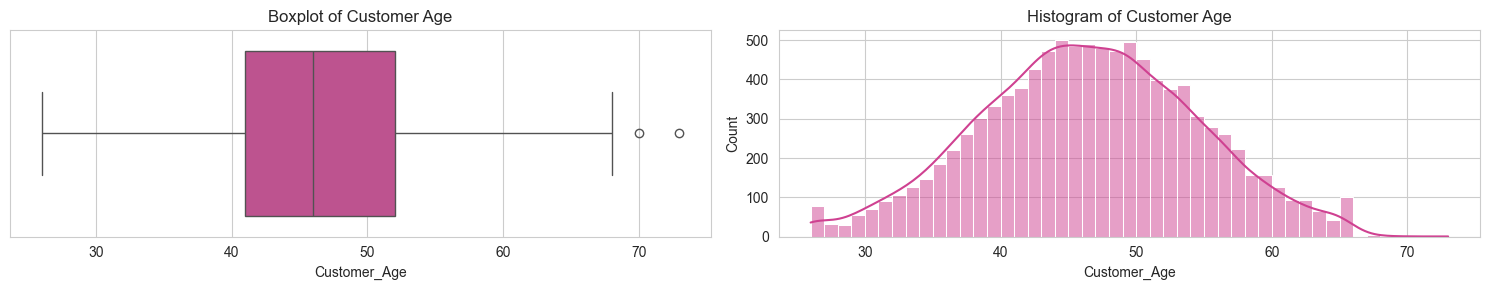

In [50]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3), tight_layout=True)

sns.boxplot(x=df_etl["Customer_Age"], ax=axes[0])
axes[0].set_title("Boxplot of Customer Age")

sns.histplot(x=df_etl["Customer_Age"], ax=axes[1], kde=True)
axes[1].set_title("Histogram of Customer Age")

plt.show()

##### **Interquartile Range Investigation**

> *Notes on Process*:
<br><br>The below method was outlined to us by Rory from Code Institute.
<br><br>

In [18]:
# Establish the Interquartile Range for Customer_Age
Q1 = df_etl["Customer_Age"].quantile(0.25)
Q3 = df_etl["Customer_Age"].quantile(0.75)
IQR = Q3 - Q1
print("="*50)
print(f"INTERQUARTILE RANGE ANALYSIS FOR CUSTOMER AGE")
print("="*50)
print(f"Q1 for Customer_Age: {Q1}")
print(f"Q3 for Customer_Age: {Q3}")
print(f"IQR for Customer_Age: {IQR}")
print("-"*50)

# Calculate the upper and lower bounds for Customer_Age
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for Customer_Age: {upper_bound:.2f}")
print(f"Lower Bound for Customer_Age: {lower_bound:.2f}")

INTERQUARTILE RANGE ANALYSIS FOR CUSTOMER AGE
Q1 for Customer_Age: 41.0
Q3 for Customer_Age: 52.0
IQR for Customer_Age: 11.0
--------------------------------------------------
Upper Bound for Customer_Age: 68.50
Lower Bound for Customer_Age: 24.50


Now we will look at the outliers: how many there are and what their values are.

In [19]:
# Review the outliers for Customer_Age
print("="*50)
print(f"OUTLIERS ANALYSIS FOR CUSTOMER AGE")
print("="*50)

# Ascertain the number of outliers above the upper bound for Customer_Age
print(f"Outliers found above the upper bound: {(df_etl['Customer_Age'] > upper_bound).sum()}")

# Ascertain the number of outliers below the lower bound for Customer_Age
print(f"Outliers found below the lower bound: {(df_etl['Customer_Age'] < lower_bound).sum()}")

OUTLIERS ANALYSIS FOR CUSTOMER AGE
Outliers found above the upper bound: 2
Outliers found below the lower bound: 0


I want to have a look at the 2 outlier values found above the upper bound to see how anomalous they are.

In [20]:
# Use value_counts() to display the outlier values and their frequencies for Customer_Age
print("="*50)
print(f"OUTLIER VALUES FOR CUSTOMER AGE")
print("="*50)

outliers_above_upper_bound_age = df_etl[df_etl["Customer_Age"] > upper_bound]
print(f"Values for Customer_Age above the upper bound:\n{outliers_above_upper_bound_age['Customer_Age'].value_counts()}")

OUTLIER VALUES FOR CUSTOMER AGE
Values for Customer_Age above the upper bound:
Customer_Age
73    1
70    1
Name: count, dtype: int64


##### *Should I Delete?*
No - these two age values are not anomalous enough that they should be deleted.

#### **2.3.2 Dependent Count**

##### **Boxplot and Histogram**

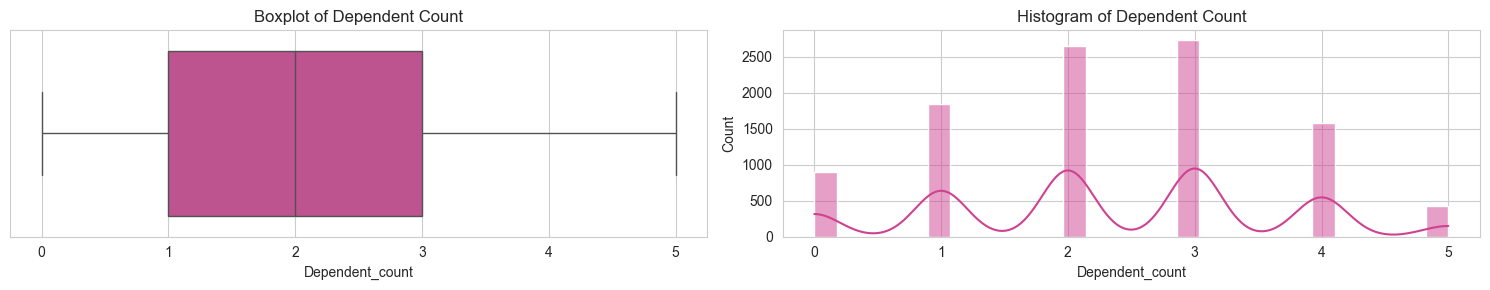

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3), tight_layout=True)

sns.boxplot(x=df_etl["Dependent_count"], ax=axes[0])
axes[0].set_title("Boxplot of Dependent Count")

sns.histplot(x=df_etl["Dependent_count"], ax=axes[1], kde=True)
axes[1].set_title("Histogram of Dependent Count")

plt.show()

##### **Interquartile Range Investigation**

In [22]:
# Establish the Interquartile Range for Dependent_count
Q1 = df_etl["Dependent_count"].quantile(0.25)
Q3 = df_etl["Dependent_count"].quantile(0.75)
IQR = Q3 - Q1
print("="*50)
print(f"INTERQUARTILE RANGE ANALYSIS FOR DEPENDENT COUNT")
print("="*50)
print(f"Q1 for Dependent_count: {Q1}")
print(f"Q3 for Dependent_count: {Q3}")
print(f"IQR for Dependent_count: {IQR}")
print("-"*50)

# Calculate the upper and lower bounds for Dependent_count
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for Dependent_count: {upper_bound:.2f}")
print(f"Lower Bound for Dependent_count: {lower_bound:.2f}\n")

# Review the outliers for Dependent_count
print("="*50)
print(f"OUTLIERS ANALYSIS FOR DEPENDENT COUNT")
print("="*50)

# Ascertain the number of outliers above the upper bound for Dependent_count
print(f"Outliers found above the upper bound: {(df_etl['Dependent_count'] > upper_bound).sum()}")

# Ascertain the number of outliers below the lower bound for Dependent_count
print(f"Outliers found below the lower bound: {(df_etl['Dependent_count'] < lower_bound).sum()}")

INTERQUARTILE RANGE ANALYSIS FOR DEPENDENT COUNT
Q1 for Dependent_count: 1.0
Q3 for Dependent_count: 3.0
IQR for Dependent_count: 2.0
--------------------------------------------------
Upper Bound for Dependent_count: 6.00
Lower Bound for Dependent_count: -2.00

OUTLIERS ANALYSIS FOR DEPENDENT COUNT
Outliers found above the upper bound: 0
Outliers found below the lower bound: 0


##### *Should I Delete?*
With no outliers for `Dependent_Count`, there are no further actions needed.

#### **2.3.3 Months on Book**

##### **Boxplot and Histogram**

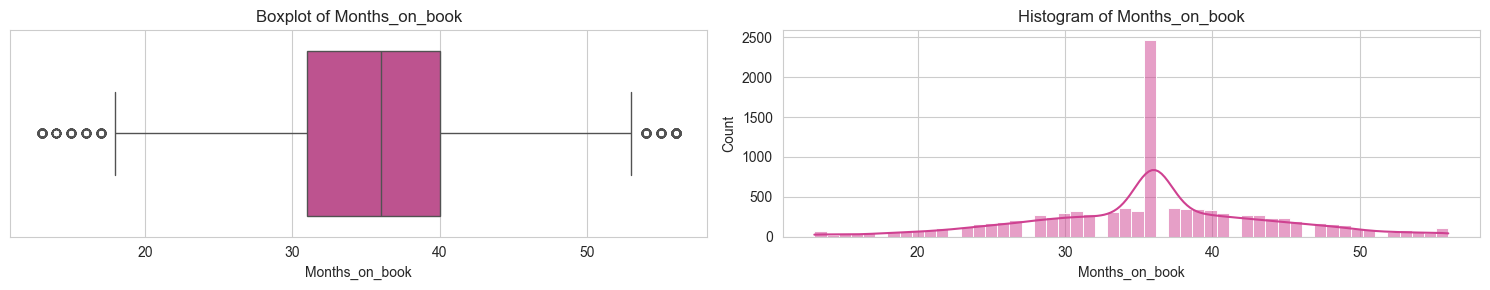

In [23]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3), tight_layout=True)

sns.boxplot(x=df_etl["Months_on_book"], ax=axes[0])
axes[0].set_title("Boxplot of Months_on_book")

sns.histplot(x=df_etl["Months_on_book"], ax=axes[1], kde=True)
axes[1].set_title("Histogram of Months_on_book")

plt.show()

##### **Interquartile Range Analysis**

In [24]:
# Establish the Interquartile Range for Months_on_book
Q1 = df_etl["Months_on_book"].quantile(0.25)
Q3 = df_etl["Months_on_book"].quantile(0.75)
IQR = Q3 - Q1
print("="*50)
print(f"INTERQUARTILE RANGE ANALYSIS FOR MONTHS ON BOOK")
print("="*50)
print(f"Q1 for Months_on_book: {Q1}")
print(f"Q3 for Months_on_book: {Q3}")
print(f"IQR for Months_on_book: {IQR}")
print("-"*50)

# Calculate the upper and lower bounds for Months_on_book
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for Months_on_book: {upper_bound:.2f}")
print(f"Lower Bound for Months_on_book: {lower_bound:.2f}\n")

# Review the outliers for Months_on_book
print("="*50)
print(f"OUTLIERS ANALYSIS FOR MONTHS ON BOOK")
print("="*50)

# Ascertain the number of outliers above the upper bound for Months_on_book
print(f"Outliers found above the upper bound: {(df_etl['Months_on_book'] > upper_bound).sum()}")

# Ascertain the number of outliers below the lower bound for Months_on_book
print(f"Outliers found below the lower bound: {(df_etl['Months_on_book'] < lower_bound).sum()}")

INTERQUARTILE RANGE ANALYSIS FOR MONTHS ON BOOK
Q1 for Months_on_book: 31.0
Q3 for Months_on_book: 40.0
IQR for Months_on_book: 9.0
--------------------------------------------------
Upper Bound for Months_on_book: 53.50
Lower Bound for Months_on_book: 17.50

OUTLIERS ANALYSIS FOR MONTHS ON BOOK
Outliers found above the upper bound: 198
Outliers found below the lower bound: 188


In [25]:
# Use value_counts() to display the outlier values and their frequencies for Months_on_book
print("="*50)
print(f"OUTLIER VALUES FOR MONTHS ON BOOK")
print("="*50)

outliers_above_upper_bound_months_on_book = df_etl[df_etl["Months_on_book"] > upper_bound]
outliers_below_lower_bound_months_on_book = df_etl[df_etl["Months_on_book"] < lower_bound]

print(f"Values for Months_on_book above the upper bound:\n{outliers_above_upper_bound_months_on_book['Months_on_book'].value_counts()}")
print("-"*50)
print(f"Values for Months_on_book below the lower bound:\n{outliers_below_lower_bound_months_on_book['Months_on_book'].value_counts()}")

OUTLIER VALUES FOR MONTHS ON BOOK
Values for Months_on_book above the upper bound:
Months_on_book
56    103
54     53
55     42
Name: count, dtype: int64
--------------------------------------------------
Values for Months_on_book below the lower bound:
Months_on_book
13    70
17    39
15    34
16    29
14    16
Name: count, dtype: int64


##### *Should I Delete?*
I have decided not to delete these outliers because there are so many customers who have been clients of the bank for the same periods of time. If there were `Months_on_book` values with only 1 customer, I might have considered removing if it was enough of an outlier.

#### **2.3.4 Number of Products Held by the Customer (Total_Relationship_Count)**

##### **Boxplot and Histogram**

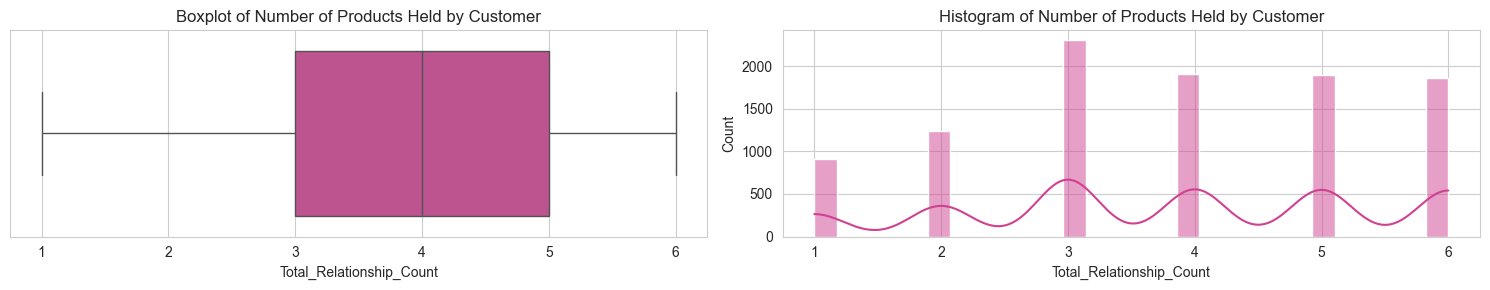

In [26]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3), tight_layout=True)

sns.boxplot(x=df_etl["Total_Relationship_Count"], ax=axes[0])
axes[0].set_title("Boxplot of Number of Products Held by Customer")

sns.histplot(x=df_etl["Total_Relationship_Count"], ax=axes[1], kde=True)
axes[1].set_title("Histogram of Number of Products Held by Customer")

plt.show()

##### **Interquartile Range Investigation**

In [27]:
# Establish the Interquartile Range for Total_Relationship_Count
Q1 = df_etl["Total_Relationship_Count"].quantile(0.25)
Q3 = df_etl["Total_Relationship_Count"].quantile(0.75)
IQR = Q3 - Q1
print("="*70)
print(f"INTERQUARTILE RANGE ANALYSIS FOR NUMBER OF PRODUCTS HELD BY CUSTOMER")
print("="*70)
print(f"Q1 for Total_Relationship_Count: {Q1}")
print(f"Q3 for Total_Relationship_Count: {Q3}")
print(f"IQR for Total_Relationship_Count: {IQR}")
print("-"*70)

# Calculate the upper and lower bounds for Total_Relationship_Count
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for Total_Relationship_Count: {upper_bound:.2f}")
print(f"Lower Bound for Total_Relationship_Count: {lower_bound:.2f}\n")

# Review the outliers for Total_Relationship_Count
print("="*70)
print(f"OUTLIERS ANALYSIS FOR NUMBER OF PRODUCTS HELD BY CUSTOMER")
print("="*70)

# Ascertain the number of outliers above the upper bound for Total_Relationship_Count
print(f"Outliers found above the upper bound: {(df_etl['Total_Relationship_Count'] > upper_bound).sum()}")

# Ascertain the number of outliers below the lower bound for Total_Relationship_Count
print(f"Outliers found below the lower bound: {(df_etl['Total_Relationship_Count'] < lower_bound).sum()}")

INTERQUARTILE RANGE ANALYSIS FOR NUMBER OF PRODUCTS HELD BY CUSTOMER
Q1 for Total_Relationship_Count: 3.0
Q3 for Total_Relationship_Count: 5.0
IQR for Total_Relationship_Count: 2.0
----------------------------------------------------------------------
Upper Bound for Total_Relationship_Count: 8.00
Lower Bound for Total_Relationship_Count: 0.00

OUTLIERS ANALYSIS FOR NUMBER OF PRODUCTS HELD BY CUSTOMER
Outliers found above the upper bound: 0
Outliers found below the lower bound: 0


##### *Should I Delete?*
As we saw from the boxplot and confirmed through the interquartile range analysis, there are no outliers that need handling.

#### **2.3.5 Months Inactive**

As this is the number of months a customer is inactive over the course of 12 months, we expect to see no anomalous outliers beyond 12 months. I will check with the same techniques to make sure.

##### **Boxplot and Histogram**

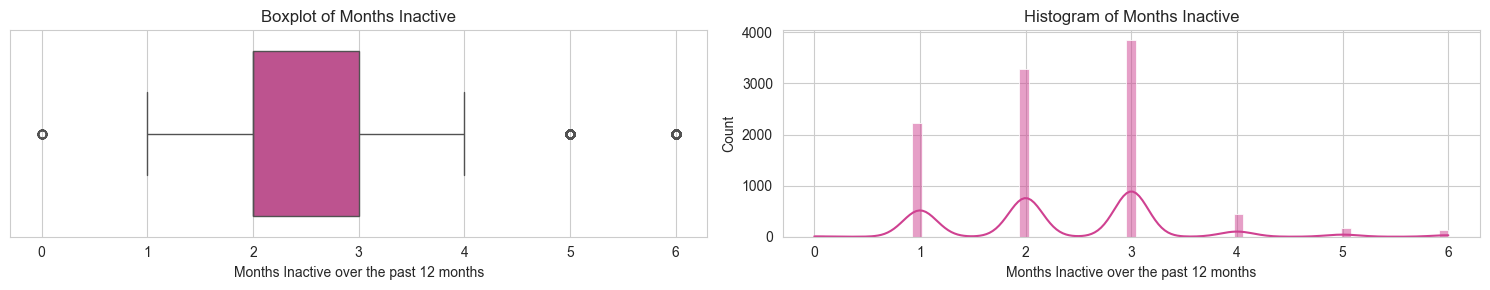

In [28]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3), tight_layout=True)

sns.boxplot(x=df_etl["Months_Inactive_12_mon"], ax=axes[0])
axes[0].set_title("Boxplot of Months Inactive")
axes[0].set_xlabel("Months Inactive over the past 12 months")

sns.histplot(x=df_etl["Months_Inactive_12_mon"], ax=axes[1], kde=True)
axes[1].set_title("Histogram of Months Inactive")
axes[1].set_xlabel("Months Inactive over the past 12 months")

plt.show()

##### **Interquartile Range Investigation**

In [29]:
# Establish the Interquartile Range for Months_Inactive_12_mon
Q1 = df_etl["Months_Inactive_12_mon"].quantile(0.25)
Q3 = df_etl["Months_Inactive_12_mon"].quantile(0.75)
IQR = Q3 - Q1
print("="*50)
print(f"INTERQUARTILE RANGE ANALYSIS FOR MONTHS INACTIVE")
print("="*50)
print(f"Q1 for Months_Inactive_12_mon: {Q1}")
print(f"Q3 for Months_Inactive_12_mon: {Q3}")
print(f"IQR for Months_Inactive_12_mon: {IQR}")
print("-"*50)

# Calculate the upper and lower bounds for Months_Inactive_12_mon
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for Months_Inactive_12_mon: {upper_bound:.2f}")
print(f"Lower Bound for Months_Inactive_12_mon: {lower_bound:.2f}\n")

# Review the outliers for Months_Inactive_12_mon
print("="*50)
print(f"OUTLIERS ANALYSIS FOR MONTHS INACTIVE")
print("="*50)

# Ascertain the number of outliers above the upper bound for Months_Inactive_12_mon
print(f"Outliers found above the upper bound: {(df_etl['Months_Inactive_12_mon'] > upper_bound).sum()}")

# Ascertain the number of outliers below the lower bound for Months_Inactive_12_mon
print(f"Outliers found below the lower bound: {(df_etl['Months_Inactive_12_mon'] < lower_bound).sum()}")

INTERQUARTILE RANGE ANALYSIS FOR MONTHS INACTIVE
Q1 for Months_Inactive_12_mon: 2.0
Q3 for Months_Inactive_12_mon: 3.0
IQR for Months_Inactive_12_mon: 1.0
--------------------------------------------------
Upper Bound for Months_Inactive_12_mon: 4.50
Lower Bound for Months_Inactive_12_mon: 0.50

OUTLIERS ANALYSIS FOR MONTHS INACTIVE
Outliers found above the upper bound: 302
Outliers found below the lower bound: 29


In [30]:
# Print the maximum and minimum values for Months_Inactive_12_mon to see if there are any extreme outliers
print("="*50)
print(f"MAXIMUM AND MINIMUM VALUES FOR MONTHS INACTIVE")
print("="*50)
print(f"Maximum value for Months_Inactive_12_mon: {df_etl['Months_Inactive_12_mon'].max()}")
print(f"Minimum value for Months_Inactive_12_mon: {df_etl['Months_Inactive_12_mon'].min()}")

MAXIMUM AND MINIMUM VALUES FOR MONTHS INACTIVE
Maximum value for Months_Inactive_12_mon: 6
Minimum value for Months_Inactive_12_mon: 0


##### *Should I Delete?*
Having conducted a test to see the maximum and minimum values for `Months_Inactive_12_mon`, I can see that there are none that are anomalous. Therefore, I will not delete any outliers.

#### **2.3.6 Number of Contacts**

##### **Boxplot and Histogram**

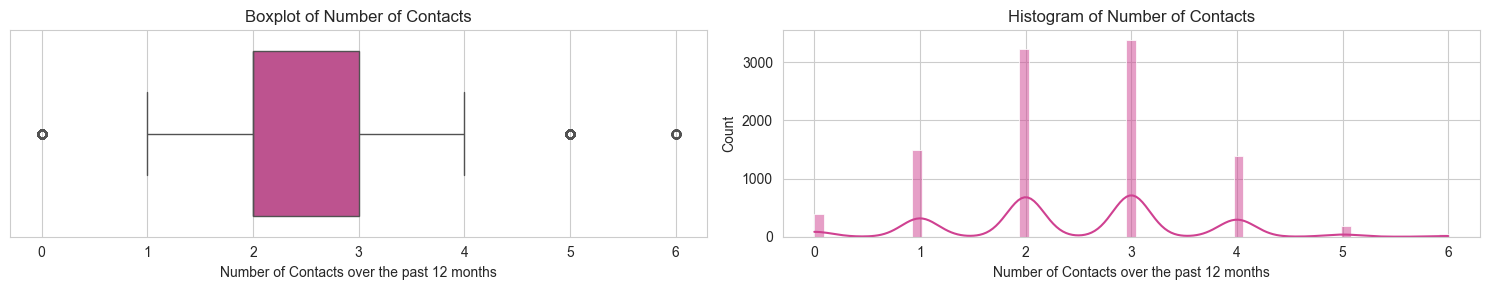

In [31]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3), tight_layout=True)

sns.boxplot(x=df_etl["Contacts_Count_12_mon"], ax=axes[0])
axes[0].set_title("Boxplot of Number of Contacts")
axes[0].set_xlabel("Number of Contacts over the past 12 months")

sns.histplot(x=df_etl["Contacts_Count_12_mon"], ax=axes[1], kde=True)
axes[1].set_title("Histogram of Number of Contacts")
axes[1].set_xlabel("Number of Contacts over the past 12 months")

plt.show()

##### **Interquartile Range Investigation**

In [32]:
# Establish the Interquartile Range for Contacts_Count_12_mon
Q1 = df_etl["Contacts_Count_12_mon"].quantile(0.25)
Q3 = df_etl["Contacts_Count_12_mon"].quantile(0.75)
IQR = Q3 - Q1
print("="*50)
print(f"INTERQUARTILE RANGE ANALYSIS FOR CONTACTS COUNT")
print("="*50)
print(f"Q1 for Contacts_Count_12_mon: {Q1}")
print(f"Q3 for Contacts_Count_12_mon: {Q3}")
print(f"IQR for Contacts_Count_12_mon: {IQR}")
print("-"*50)

# Calculate the upper and lower bounds for Contacts_Count_12_mon
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for Contacts_Count_12_mon: {upper_bound:.2f}")
print(f"Lower Bound for Contacts_Count_12_mon: {lower_bound:.2f}\n")

# Review the outliers for Contacts_Count_12_mon
print("="*50)
print(f"OUTLIERS ANALYSIS FOR CONTACTS COUNT")
print("="*50)

# Ascertain the number of outliers above the upper bound for Contacts_Count_12_mon
print(f"Outliers found above the upper bound: {(df_etl['Contacts_Count_12_mon'] > upper_bound).sum()}")

# Ascertain the number of outliers below the lower bound for Contacts_Count_12_mon
print(f"Outliers found below the lower bound: {(df_etl['Contacts_Count_12_mon'] < lower_bound).sum()}")

INTERQUARTILE RANGE ANALYSIS FOR CONTACTS COUNT
Q1 for Contacts_Count_12_mon: 2.0
Q3 for Contacts_Count_12_mon: 3.0
IQR for Contacts_Count_12_mon: 1.0
--------------------------------------------------
Upper Bound for Contacts_Count_12_mon: 4.50
Lower Bound for Contacts_Count_12_mon: 0.50

OUTLIERS ANALYSIS FOR CONTACTS COUNT
Outliers found above the upper bound: 230
Outliers found below the lower bound: 399


In [33]:
# Print the maximum and minimum values for Contacts_Count_12_mon to see if there are any extreme outliers
print("="*50)
print(f"MAXIMUM AND MINIMUM VALUES FOR CONTACTS COUNT")
print("="*50)
print(f"Maximum value for Contacts_Count_12_mon: {df_etl['Contacts_Count_12_mon'].max()}")
print(f"Minimum value for Contacts_Count_12_mon: {df_etl['Contacts_Count_12_mon'].min()}")

MAXIMUM AND MINIMUM VALUES FOR CONTACTS COUNT
Maximum value for Contacts_Count_12_mon: 6
Minimum value for Contacts_Count_12_mon: 0


##### *Should I Delete?*
As I did with the `Months_Inactive_12_mon`, I wanted to have a look at the maximum and minimum values for `Contacts_Count_12_mon` to ascertain the total range of the column values and what that looked like compared to the upper and lower bounds. Despite there being a fair amount of outliers found, the maximum and minimum values suggest that all of these values aren't far-enough removed to warrant deletion.

#### **2.3.7 Credit Limit**

##### **Boxplot and Histogram**

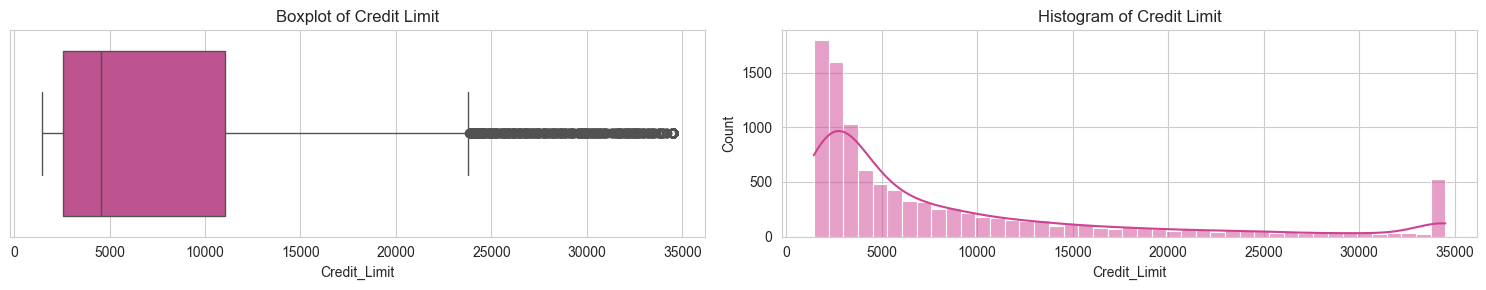

In [34]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3), tight_layout=True)

sns.boxplot(x=df_etl["Credit_Limit"], ax=axes[0])
axes[0].set_title("Boxplot of Credit Limit")

sns.histplot(x=df_etl["Credit_Limit"], ax=axes[1], kde=True)
axes[1].set_title("Histogram of Credit Limit")

plt.show()

##### **Interquartile Range Investigation**

In [35]:
# Establish the Interquartile Range for Credit_Limit
Q1 = df_etl["Credit_Limit"].quantile(0.25)
Q3 = df_etl["Credit_Limit"].quantile(0.75)
IQR = Q3 - Q1
print("="*50)
print(f"INTERQUARTILE RANGE ANALYSIS FOR CREDIT LIMIT")
print("="*50)
print(f"Q1 for Credit_Limit: {Q1}")
print(f"Q3 for Credit_Limit: {Q3}")
print(f"IQR for Credit_Limit: {IQR}")
print("-"*50)

# Calculate the upper and lower bounds for Credit_Limit
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for Credit_Limit: {upper_bound:.2f}")
print(f"Lower Bound for Credit_Limit: {lower_bound:.2f}\n")

# Review the outliers for Credit_Limit
print("="*50)
print(f"OUTLIERS ANALYSIS FOR CREDIT LIMIT")
print("="*50)

# Ascertain the number of outliers above the upper bound for Credit_Limit
print(f"Outliers found above the upper bound: {(df_etl['Credit_Limit'] > upper_bound).sum()}")

# Ascertain the number of outliers below the lower bound for Credit_Limit
print(f"Outliers found below the lower bound: {(df_etl['Credit_Limit'] < lower_bound).sum()}")

INTERQUARTILE RANGE ANALYSIS FOR CREDIT LIMIT
Q1 for Credit_Limit: 2555.0
Q3 for Credit_Limit: 11067.5
IQR for Credit_Limit: 8512.5
--------------------------------------------------
Upper Bound for Credit_Limit: 23836.25
Lower Bound for Credit_Limit: -10213.75

OUTLIERS ANALYSIS FOR CREDIT LIMIT
Outliers found above the upper bound: 984
Outliers found below the lower bound: 0


##### *Should I Delete?*
There are a very large group of outliers for `Credit_Limit`. What's interesting if we look at the histogram is that we appear to have almost an inverted bell curve - frequency is most high at the lowest credit limits, but then there is a big uptick in frequency at the highest values also. This would be an interesting thing to investigate further so the outliers should not be removed.

#### **2.3.8 Total Revolving Balance**

##### **Boxplot and Histogram**

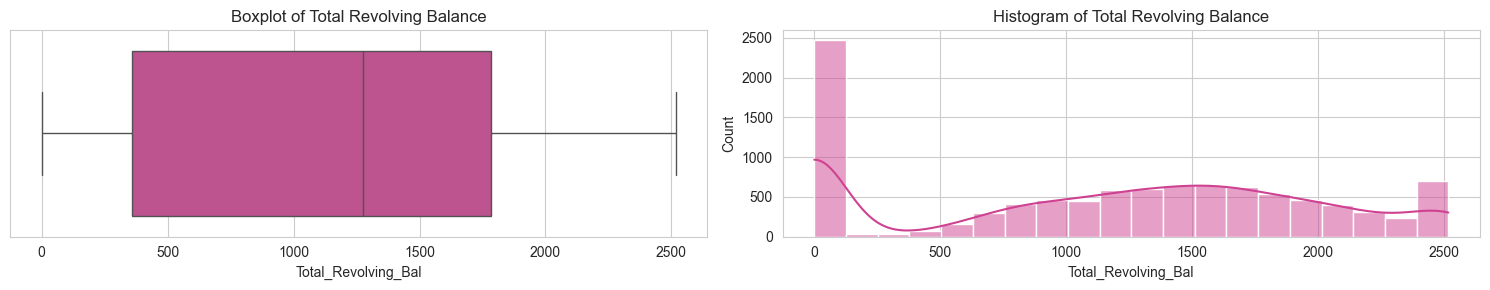

In [36]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3), tight_layout=True)

sns.boxplot(x=df_etl["Total_Revolving_Bal"], ax=axes[0])
axes[0].set_title("Boxplot of Total Revolving Balance")

sns.histplot(x=df_etl["Total_Revolving_Bal"], ax=axes[1], kde=True)
axes[1].set_title("Histogram of Total Revolving Balance")

plt.show()

##### **Interquartile Range Investigation**

In [37]:
# Establish the Interquartile Range for Total_Revolving_Bal
Q1 = df_etl["Total_Revolving_Bal"].quantile(0.25)
Q3 = df_etl["Total_Revolving_Bal"].quantile(0.75)
IQR = Q3 - Q1
print("="*50)
print(f"INTERQUARTILE RANGE ANALYSIS FOR REVOLVING BALANCE")
print("="*50)
print(f"Q1 for Total_Revolving_Bal: {Q1}")
print(f"Q3 for Total_Revolving_Bal: {Q3}")
print(f"IQR for Total_Revolving_Bal: {IQR}")
print("-"*50)

# Calculate the upper and lower bounds for Total_Revolving_Bal
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for Total_Revolving_Bal: {upper_bound:.2f}")
print(f"Lower Bound for Total_Revolving_Bal: {lower_bound:.2f}\n")

# Review the outliers for Total_Revolving_Bal
print("="*50)
print(f"OUTLIERS ANALYSIS FOR REVOLVING BALANCE")
print("="*50)

# Ascertain the number of outliers above the upper bound for Total_Revolving_Bal
print(f"Outliers found above the upper bound: {(df_etl['Total_Revolving_Bal'] > upper_bound).sum()}")

# Ascertain the number of outliers below the lower bound for Total_Revolving_Bal
print(f"Outliers found below the lower bound: {(df_etl['Total_Revolving_Bal'] < lower_bound).sum()}")

INTERQUARTILE RANGE ANALYSIS FOR REVOLVING BALANCE
Q1 for Total_Revolving_Bal: 359.0
Q3 for Total_Revolving_Bal: 1784.0
IQR for Total_Revolving_Bal: 1425.0
--------------------------------------------------
Upper Bound for Total_Revolving_Bal: 3921.50
Lower Bound for Total_Revolving_Bal: -1778.50

OUTLIERS ANALYSIS FOR REVOLVING BALANCE
Outliers found above the upper bound: 0
Outliers found below the lower bound: 0


##### *Should I Delete?*
There are not outliers identified, so no further action required for this section.

#### **2.3.9 Average Open to Buy**

##### **Boxplot and Histogram**

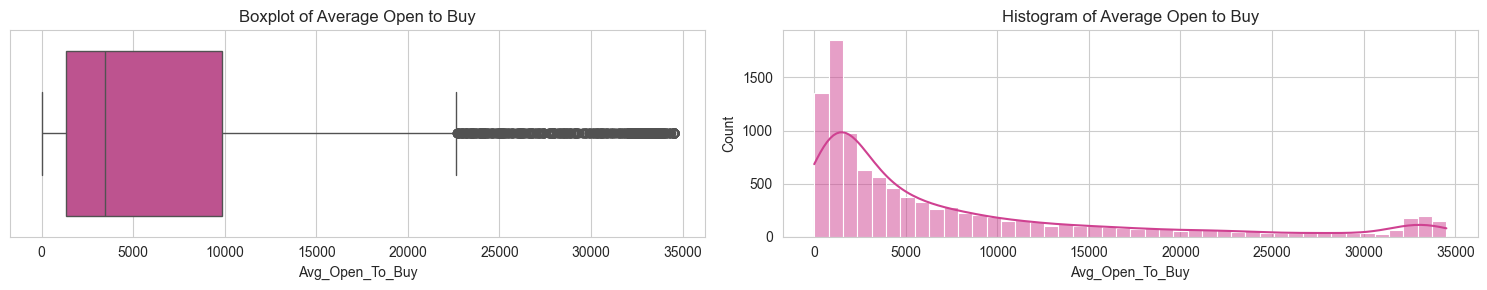

In [38]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3), tight_layout=True)

sns.boxplot(x=df_etl["Avg_Open_To_Buy"], ax=axes[0])
axes[0].set_title("Boxplot of Average Open to Buy")

sns.histplot(x=df_etl["Avg_Open_To_Buy"], ax=axes[1], kde=True)
axes[1].set_title("Histogram of Average Open to Buy")

plt.show()

##### **Interquartile Range Investigation**

In [39]:
# Establish the Interquartile Range for Avg_Open_To_Buy
Q1 = df_etl["Avg_Open_To_Buy"].quantile(0.25)
Q3 = df_etl["Avg_Open_To_Buy"].quantile(0.75)
IQR = Q3 - Q1
print("="*54)
print(f"INTERQUARTILE RANGE ANALYSIS FOR AVERAGE OPEN TO BUY")
print("="*54)
print(f"Q1 for Avg_Open_To_Buy: {Q1}")
print(f"Q3 for Avg_Open_To_Buy: {Q3}")
print(f"IQR for Avg_Open_To_Buy: {IQR}")
print("-"*54)

# Calculate the upper and lower bounds for Avg_Open_To_Buy
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for Avg_Open_To_Buy: {upper_bound:.2f}")
print(f"Lower Bound for Avg_Open_To_Buy: {lower_bound:.2f}\n")

# Review the outliers for Avg_Open_To_Buy
print("="*54)
print(f"OUTLIERS ANALYSIS FOR AVERAGE OPEN TO BUY")
print("="*54)

# Ascertain the number of outliers above the upper bound for Avg_Open_To_Buy
print(f"Outliers found above the upper bound: {(df_etl['Avg_Open_To_Buy'] > upper_bound).sum()}")

# Ascertain the number of outliers below the lower bound for Avg_Open_To_Buy
print(f"Outliers found below the lower bound: {(df_etl['Avg_Open_To_Buy'] < lower_bound).sum()}")

INTERQUARTILE RANGE ANALYSIS FOR AVERAGE OPEN TO BUY
Q1 for Avg_Open_To_Buy: 1324.5
Q3 for Avg_Open_To_Buy: 9859.0
IQR for Avg_Open_To_Buy: 8534.5
------------------------------------------------------
Upper Bound for Avg_Open_To_Buy: 22660.75
Lower Bound for Avg_Open_To_Buy: -11477.25

OUTLIERS ANALYSIS FOR AVERAGE OPEN TO BUY
Outliers found above the upper bound: 963
Outliers found below the lower bound: 0


##### *Should I Delete?*
The distributions for `Credit_Limit` and `Avg_Open_To_Buy`) are very similar (most clear when visualised via histograms). This makes sense because Average Open-to-Buy is calculated as roughly Total Credit Limit - Revolving Balance. It therefore makes sense that `Credit_Limit` and `Avg_Open_To_Buy` would show similar-shaped distributions, since one is derived from the other (with `Total_Revolving_Bal` as the adjustment). Ultimately, since I've made the decision not to delete the outliers for Credit Limit, I won't do so for this column either.

#### **2.3.10 Change in Transaction Amount**

##### **Boxplot and Histogram**

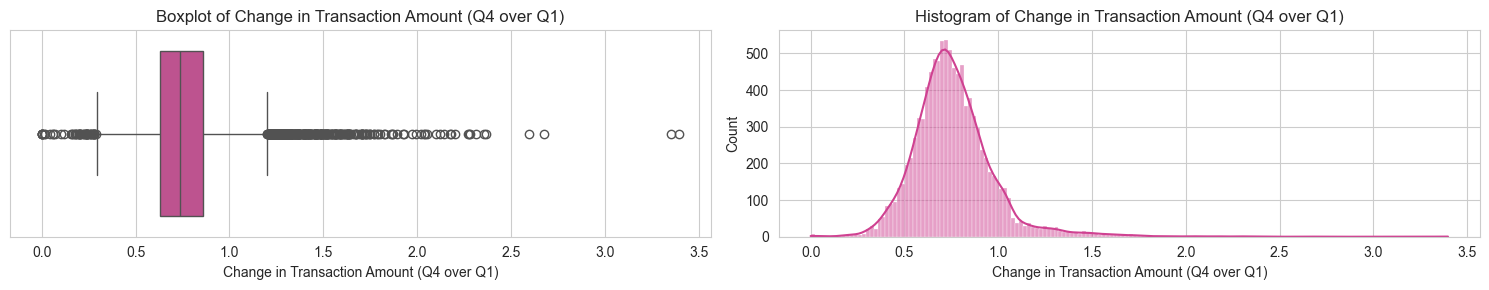

In [40]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3), tight_layout=True)

sns.boxplot(x=df_etl["Total_Amt_Chng_Q4_Q1"], ax=axes[0])
axes[0].set_title("Boxplot of Change in Transaction Amount (Q4 over Q1)")
axes[0].set_xlabel("Change in Transaction Amount (Q4 over Q1)")

sns.histplot(x=df_etl["Total_Amt_Chng_Q4_Q1"], ax=axes[1], kde=True)
axes[1].set_title("Histogram of Change in Transaction Amount (Q4 over Q1)")
axes[1].set_xlabel("Change in Transaction Amount (Q4 over Q1)")

plt.show()

##### **Interquartile Range Investigation**

In [41]:
# Establish the Interquartile Range for Total_Amt_Chng_Q4_Q1
Q1 = df_etl["Total_Amt_Chng_Q4_Q1"].quantile(0.25)
Q3 = df_etl["Total_Amt_Chng_Q4_Q1"].quantile(0.75)
IQR = Q3 - Q1
print("="*65)
print(f"INTERQUARTILE RANGE ANALYSIS FOR CHANGE IN TRANSACTION AMOUNT")
print("="*65)
print(f"Q1 for Total_Amt_Chng_Q4_Q1: {Q1}")
print(f"Q3 for Total_Amt_Chng_Q4_Q1: {Q3}")
print(f"IQR for Total_Amt_Chng_Q4_Q1: {IQR}")
print("-"*65)

# Calculate the upper and lower bounds for Total_Amt_Chng_Q4_Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for Total_Amt_Chng_Q4_Q1: {upper_bound:.2f}")
print(f"Lower Bound for Total_Amt_Chng_Q4_Q1: {lower_bound:.2f}\n")

# Review the outliers for Total_Amt_Chng_Q4_Q1
print("="*65)
print(f"OUTLIERS ANALYSIS FOR CHANGE IN TRANSACTION AMOUNT")
print("="*65)


# Ascertain the number of outliers above the upper bound for Total_Amt_Chng_Q4_Q1
print(f"Outliers found above the upper bound: {(df_etl['Total_Amt_Chng_Q4_Q1'] > upper_bound).sum()}")

# Ascertain the number of outliers below the lower bound for Total_Amt_Chng_Q4_Q1
print(f"Outliers found below the lower bound: {(df_etl['Total_Amt_Chng_Q4_Q1'] < lower_bound).sum()}")

INTERQUARTILE RANGE ANALYSIS FOR CHANGE IN TRANSACTION AMOUNT
Q1 for Total_Amt_Chng_Q4_Q1: 0.631
Q3 for Total_Amt_Chng_Q4_Q1: 0.859
IQR for Total_Amt_Chng_Q4_Q1: 0.22799999999999998
-----------------------------------------------------------------
Upper Bound for Total_Amt_Chng_Q4_Q1: 1.20
Lower Bound for Total_Amt_Chng_Q4_Q1: 0.29

OUTLIERS ANALYSIS FOR CHANGE IN TRANSACTION AMOUNT
Outliers found above the upper bound: 348
Outliers found below the lower bound: 48


##### *Should I Delete?*
Given that this variable measures a ratio of change that gives a clear indication of customer behaviour, the outliers might be incredibly useful in predicting whether a customer is likely to be attrited or not. Therefore, I have made the decision not to delete these outliers.

#### **2.3.11 Total Transaction Amount**

##### **Boxplot and Histogram**

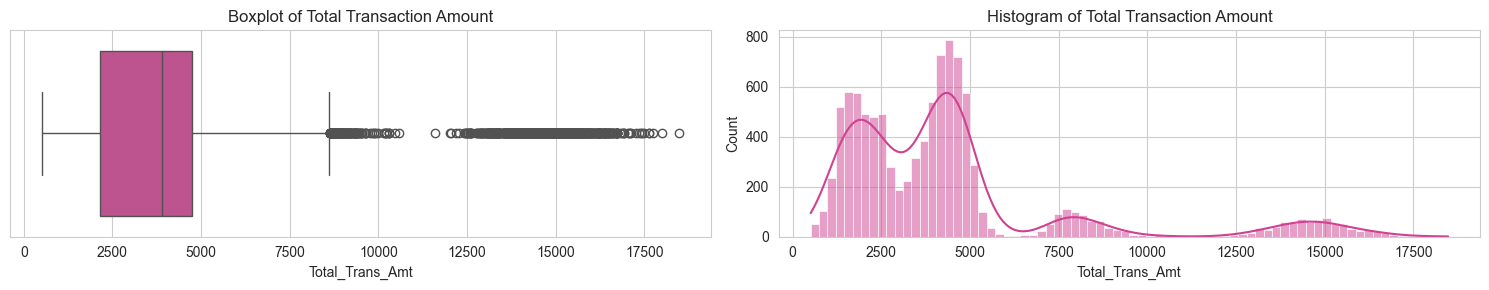

In [42]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3), tight_layout=True)

sns.boxplot(x=df_etl["Total_Trans_Amt"], ax=axes[0])
axes[0].set_title("Boxplot of Total Transaction Amount")

sns.histplot(x=df_etl["Total_Trans_Amt"], ax=axes[1], kde=True)
axes[1].set_title("Histogram of Total Transaction Amount")

plt.show()

##### **Interquartile Range Investigation**

In [43]:
# Establish the Interquartile Range for Total_Trans_Amt
Q1 = df_etl["Total_Trans_Amt"].quantile(0.25)
Q3 = df_etl["Total_Trans_Amt"].quantile(0.75)
IQR = Q3 - Q1
print("="*60)
print(f"INTERQUARTILE RANGE ANALYSIS FOR TOTAL TRANSACTION AMOUNT")
print("="*60)
print(f"Q1 for Total_Trans_Amt: {Q1}")
print(f"Q3 for Total_Trans_Amt: {Q3}")
print(f"IQR for Total_Trans_Amt: {IQR}")
print("-"*60)

# Calculate the upper and lower bounds for Total_Trans_Amt
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for Total_Trans_Amt: {upper_bound:.2f}")
print(f"Lower Bound for Total_Trans_Amt: {lower_bound:.2f}\n")

# Review the outliers for Total_Trans_Amt
print("="*60)
print(f"OUTLIERS ANALYSIS FOR TOTAL TRANSACTION AMOUNT")
print("="*60)


# Ascertain the number of outliers above the upper bound for Total_Trans_Amt
print(f"Outliers found above the upper bound: {(df_etl['Total_Trans_Amt'] > upper_bound).sum()}")

# Ascertain the number of outliers below the lower bound for Total_Trans_Amt
print(f"Outliers found below the lower bound: {(df_etl['Total_Trans_Amt'] < lower_bound).sum()}")

INTERQUARTILE RANGE ANALYSIS FOR TOTAL TRANSACTION AMOUNT
Q1 for Total_Trans_Amt: 2155.5
Q3 for Total_Trans_Amt: 4741.0
IQR for Total_Trans_Amt: 2585.5
------------------------------------------------------------
Upper Bound for Total_Trans_Amt: 8619.25
Lower Bound for Total_Trans_Amt: -1722.75

OUTLIERS ANALYSIS FOR TOTAL TRANSACTION AMOUNT
Outliers found above the upper bound: 896
Outliers found below the lower bound: 0


##### *Should I Delete?*
I have decided not to delete the large number of outliers for `Total_Transaction_Amt` because I want to explore this in my **H1** in **Stage 3 - Visualisation**. The number of outliers represents 8.8% of the data and with this much flagged as "outliers" I am likely to actually be deleting a genuine subpopulation of the data rather than just noise.

#### **2.3.12 Total Transaction Count**

##### **Boxplot and Histogram**

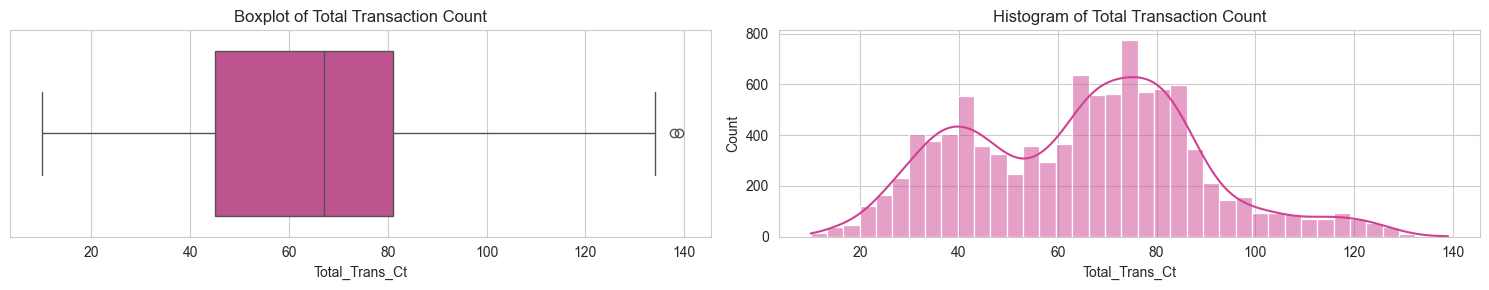

In [44]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3), tight_layout=True)

sns.boxplot(x=df_etl["Total_Trans_Ct"], ax=axes[0])
axes[0].set_title("Boxplot of Total Transaction Count")

sns.histplot(x=df_etl["Total_Trans_Ct"], ax=axes[1], kde=True)
axes[1].set_title("Histogram of Total Transaction Count")

plt.show()

##### **Interquartile Range Investigation**

In [45]:
# Establish the Interquartile Range for Total_Trans_Ct
Q1 = df_etl["Total_Trans_Ct"].quantile(0.25)
Q3 = df_etl["Total_Trans_Ct"].quantile(0.75)
IQR = Q3 - Q1
print("="*56)
print(f"INTERQUARTILE RANGE ANALYSIS FOR TOTAL TRANSACTION COUNT")
print("="*56)
print(f"Q1 for Total_Trans_Ct: {Q1}")
print(f"Q3 for Total_Trans_Ct: {Q3}")
print(f"IQR for Total_Trans_Ct: {IQR}")
print("-"*56)

# Calculate the upper and lower bounds for Total_Trans_Ct
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for Total_Trans_Ct: {upper_bound:.2f}")
print(f"Lower Bound for Total_Trans_Ct: {lower_bound:.2f}\n")

# Review the outliers for Total_Trans_Ct
print("="*56)
print(f"OUTLIERS ANALYSIS FOR TOTAL TRANSACTION COUNT")
print("="*56)

# Ascertain the number of outliers above the upper bound for Total_Trans_Ct
print(f"Outliers found above the upper bound: {(df_etl['Total_Trans_Ct'] > upper_bound).sum()}")

# Ascertain the number of outliers below the lower bound for Total_Trans_Ct
print(f"Outliers found below the lower bound: {(df_etl['Total_Trans_Ct'] < lower_bound).sum()}\n")

# Use value_counts() to display the outlier values and their frequencies for Total_Trans_Ct
print("="*56)
print(f"OUTLIER VALUES FOR TRANSACTION COUNT")
print("="*56)

outliers_above_upper_bound_trans_ct = df_etl[df_etl["Total_Trans_Ct"] > upper_bound]
print(f"Values for Total_Trans_Ct above the upper bound:\n{outliers_above_upper_bound_trans_ct['Total_Trans_Ct'].value_counts()}")

INTERQUARTILE RANGE ANALYSIS FOR TOTAL TRANSACTION COUNT
Q1 for Total_Trans_Ct: 45.0
Q3 for Total_Trans_Ct: 81.0
IQR for Total_Trans_Ct: 36.0
--------------------------------------------------------
Upper Bound for Total_Trans_Ct: 135.00
Lower Bound for Total_Trans_Ct: -9.00

OUTLIERS ANALYSIS FOR TOTAL TRANSACTION COUNT
Outliers found above the upper bound: 2
Outliers found below the lower bound: 0

OUTLIER VALUES FOR TRANSACTION COUNT
Values for Total_Trans_Ct above the upper bound:
Total_Trans_Ct
139    1
138    1
Name: count, dtype: int64


##### *Should I Delete?*
In this instance, the two outliers are not far-enough removed from the upper bound to delete.

#### **3.2.13 Change in Transaction Count**

##### **Boxplot and Histogram**

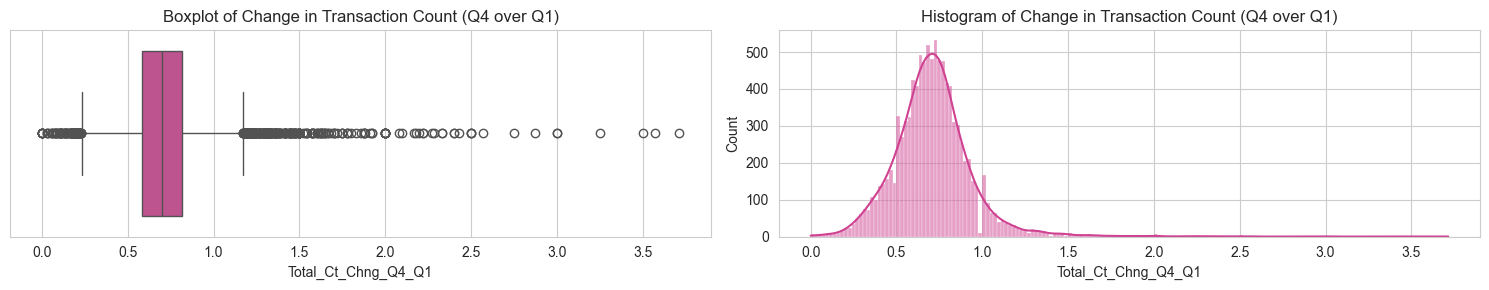

In [46]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3), tight_layout=True)

sns.boxplot(x=df_etl["Total_Ct_Chng_Q4_Q1"], ax=axes[0])
axes[0].set_title("Boxplot of Change in Transaction Count (Q4 over Q1)")

sns.histplot(x=df_etl["Total_Ct_Chng_Q4_Q1"], ax=axes[1], kde=True)
axes[1].set_title("Histogram of Change in Transaction Count (Q4 over Q1)")

plt.show()

##### **Interquartile Range Investigation**

In [47]:
# Establish the Interquartile Range for Total_Ct_Chng_Q4_Q1
Q1 = df_etl["Total_Ct_Chng_Q4_Q1"].quantile(0.25)
Q3 = df_etl["Total_Ct_Chng_Q4_Q1"].quantile(0.75)
IQR = Q3 - Q1
print("="*60)
print(f"INTERQUARTILE RANGE ANALYSIS FOR CHANGE IN TRANSACTION COUNT")
print("="*60)
print(f"Q1 for Total_Ct_Chng_Q4_Q1: {Q1}")
print(f"Q3 for Total_Ct_Chng_Q4_Q1: {Q3}")
print(f"IQR for Total_Ct_Chng_Q4_Q1: {IQR}")
print("-"*60)

# Calculate the upper and lower bounds for Total_Ct_Chng_Q4_Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for Total_Ct_Chng_Q4_Q1: {upper_bound:.2f}")
print(f"Lower Bound for Total_Ct_Chng_Q4_Q1: {lower_bound:.2f}\n")

# Review the outliers for Total_Ct_Chng_Q4_Q1
print("="*60)
print(f"OUTLIERS ANALYSIS FOR CHANGE IN TRANSACTION COUNT")
print("="*60)

# Ascertain the number of outliers above the upper bound for Total_Ct_Chng_Q4_Q1
print(f"Outliers found above the upper bound: {(df_etl['Total_Ct_Chng_Q4_Q1'] > upper_bound).sum()}")

# Ascertain the number of outliers below the lower bound for Total_Ct_Chng_Q4_Q1
print(f"Outliers found below the lower bound: {(df_etl['Total_Ct_Chng_Q4_Q1'] < lower_bound).sum()}")

INTERQUARTILE RANGE ANALYSIS FOR CHANGE IN TRANSACTION COUNT
Q1 for Total_Ct_Chng_Q4_Q1: 0.582
Q3 for Total_Ct_Chng_Q4_Q1: 0.818
IQR for Total_Ct_Chng_Q4_Q1: 0.236
------------------------------------------------------------
Upper Bound for Total_Ct_Chng_Q4_Q1: 1.17
Lower Bound for Total_Ct_Chng_Q4_Q1: 0.23

OUTLIERS ANALYSIS FOR CHANGE IN TRANSACTION COUNT
Outliers found above the upper bound: 298
Outliers found below the lower bound: 96


##### *Should I Delete?*
Using the same logic that I used for `Total_Amt_Chng_Q4_Q1`, because this variable measures a ratio of change that gives a clear indication of customer behaviour, the outliers might be incredibly useful in predicting whether a customer is likely to be attrited or not. Therefore, I have made the decision not to delete these outliers.

#### **2.3.14 Average Utilisation**

##### **Boxplot and Histogram**

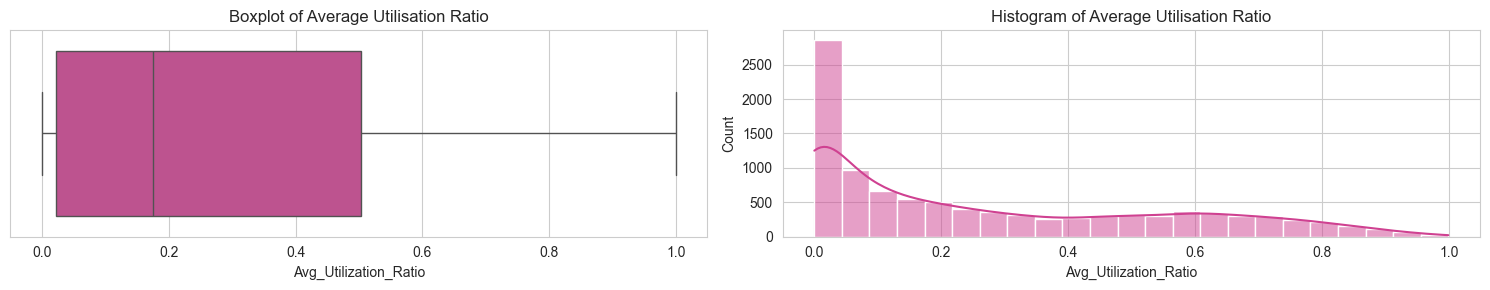

In [48]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 3), tight_layout=True)

sns.boxplot(x=df_etl["Avg_Utilization_Ratio"], ax=axes[0])
axes[0].set_title("Boxplot of Average Utilisation Ratio")

sns.histplot(x=df_etl["Avg_Utilization_Ratio"], ax=axes[1], kde=True)
axes[1].set_title("Histogram of Average Utilisation Ratio")

plt.show()

##### **Interquartile Range Investigation**

In [49]:
# Establish the Interquartile Range for Avg_Utilization_Ratio
Q1 = df_etl["Avg_Utilization_Ratio"].quantile(0.25)
Q3 = df_etl["Avg_Utilization_Ratio"].quantile(0.75)
IQR = Q3 - Q1
print("="*65)
print(f"INTERQUARTILE RANGE ANALYSIS FOR AVERAGE CARD UTILISATION RATIO")
print("="*65)
print(f"Q1 for Avg_Utilization_Ratio: {Q1}")
print(f"Q3 for Avg_Utilization_Ratio: {Q3}")
print(f"IQR for Avg_Utilization_Ratio: {IQR}")
print("-"*65)

# Calculate the upper and lower bounds for Avg_Utilization_Ratio
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for Avg_Utilization_Ratio: {upper_bound:.2f}")
print(f"Lower Bound for Avg_Utilization_Ratio: {lower_bound:.2f}\n")

# Review the outliers for Avg_Utilization_Ratio
print("="*65)
print(f"OUTLIERS ANALYSIS FOR AVERAGE CARD UTILISATION RATIO")
print("="*65)

# Ascertain the number of outliers above the upper bound for Avg_Utilization_Ratio
print(f"Outliers found above the upper bound: {(df_etl['Avg_Utilization_Ratio'] > upper_bound).sum()}")

# Ascertain the number of outliers below the lower bound for Avg_Utilization_Ratio
print(f"Outliers found below the lower bound: {(df_etl['Avg_Utilization_Ratio'] < lower_bound).sum()}")

INTERQUARTILE RANGE ANALYSIS FOR AVERAGE CARD UTILISATION RATIO
Q1 for Avg_Utilization_Ratio: 0.023
Q3 for Avg_Utilization_Ratio: 0.503
IQR for Avg_Utilization_Ratio: 0.48
-----------------------------------------------------------------
Upper Bound for Avg_Utilization_Ratio: 1.22
Lower Bound for Avg_Utilization_Ratio: -0.70

OUTLIERS ANALYSIS FOR AVERAGE CARD UTILISATION RATIO
Outliers found above the upper bound: 0
Outliers found below the lower bound: 0


##### *Should I Delete?*
There are no outliers to hande for this variable.

### **2.4 Feature Engineering**

I know that I will be looking to apply a machine learning model with the aim to predict whether a customer is an `Existing Customer` or an `Attrited Customer`. With that in mind, I will look to encode the column by creating a new one: `Attrition_Flag_Binary`. Because the model will be a predictor of attrition, I will code as `Existing Customer` = 0 and `Attrited Customer` = 1.

In [51]:
# Create a new feature column with `Existing_Customer` and `Attrited_Customer` values replaced with 0 and 1 respectively
df_etl["Attrition_Flag_Binary"] = df_etl["Attrition_Flag"].map({"Existing Customer": 0, "Attrited Customer": 1})


# Validate that the mapping has worked by displaying the unique values in the `Attrition_Flag_Binary` column
print(f"Unique values in Attrition_Flag_Binary column after mapping:\n{df_etl['Attrition_Flag_Binary'].unique()}")

df_etl.head()

Unique values in Attrition_Flag_Binary column after mapping:
[0 1]


,anonymised_clientnum,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Attrition_Flag_Binary
0,022e52f0a251431f954db620fd0c87ac3c523c60cc5980...,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,3,12691.0,777.0,11914.0,1.335,1144.0,42,1.625,0.061,0
1,2731de4ed9ecb2a3ab828448bfda6137e5c7571e1f7576...,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,2,8256.0,864.0,7392.0,1.541,1291.0,33,3.714,0.105,0
2,75dac624c2bbdb15b16abc0350820bcf598c012a76b102...,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,0,3418.0,0.0,3418.0,2.594,1887.0,20,2.333,0.000,0
3,1aaada0cd1f7dc23d83a171beec9f398cfac1471841843...,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,1,3313.0,2517.0,796.0,1.405,1171.0,20,2.333,0.760,0
4,1811f55b3210153f77e41ceceb61cc181d2edc4e65947e...,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,0,4716.0,0.0,4716.0,2.175,816.0,28,2.500,0.000,0


The rationale for not one hot coding the rest of the categorical data at this stage is because I will be doing this in the pipeline of my machine learning model.

---

## **3. Load**

The final step is to save the cleaned data CSV file that we can use in the **Stage 3 - Visualisation** section.
* I will name this file `bank-churners-cleaned.csv`

In [52]:
df_etl.to_csv("datasets/cleaned-data/bank-churners-cleaned.csv", index=False)

---

## **4. Conclusion**

In this notebook, I carried out the ETL process on the anonymised bank churners dataset and it is now ready to be used in **Stage 3 - Visualisation**.
* I loaded the dataset and displayed summary statistics.
* I changed the data type of two columns - `Total_Trans_Amt` and `Total_Revolving_Bal`
* I analysed my categorical columns and looked through value counts to ensure there were no inconsistencies with spelling or whitespace (removed with `.strip`). 
* I made decisions regarding the outliers in each of the numerical columns.
* Finally, I encoded the column `Attrition_Flag` because I will be using this as my target in my machine learning section.

---